# Notebook 3 — Normal Mileage Variation (2023–2025)

**Aim:** measure how much a vehicle's annual mileage normally varies using only intervals ending in 2023, 2024, or 2025.

This is a shorter-period companion to `03_mileage_variation.ipynb`. It reads the same valid interval output from Notebook 2, but does not alter or overwrite the six-year analysis. The previous test for a 2023 interval may be in 2022; Notebook 2 has already calculated that interval correctly, and the interval is selected because its current test date falls in the requested window.

**Produces:** `processed_data/vehicle_consistency_profiles_2023_2025.parquet` and `processed_data/quality_summary_stage3_2023_2025.json`.

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate_dir in [Path.cwd(), Path.cwd() / 'mileage_prediction']:
    if (candidate_dir / 'config.py').exists() or (candidate_dir / 'config' / '__init__.py').exists():
        sys.path.insert(0, str(candidate_dir))
        break

import config

ANALYSIS_START = pd.Timestamp('2023-01-01')
ANALYSIS_END = pd.Timestamp('2025-12-31 23:59:59.999999999')
ANALYSIS_LABEL = '2023_2025'

print(f'Analysis window: {ANALYSIS_START.date()} to {ANALYSIS_END.date()}')
print(f'Processed data folder: {config.PROCESSED_DATA_DIR}')
print(f'Minimum valid intervals for a full profile: {config.MIN_INTERVALS_FOR_VARIATION_PROFILE}')

Analysis window: 2023-01-01 to 2025-12-31
Processed data folder: /Users/matthewsalter/Documents/Development/eVED work/data-science/processed_data
Minimum valid intervals for a full profile: 3


## Step 1: load valid intervals ending in 2023–2025

The interval quality filter is pushed down to the Parquet reader. The date window is then applied to `test_date`, so a 2023 interval can use its valid 2022 predecessor.

In [3]:
intervals_input_dir = config.PROCESSED_DATA_DIR / 'vehicle_intervals'
if not intervals_input_dir.exists():
    raise FileNotFoundError(f'Could not find {intervals_input_dir}. Run 02_vehicle_intervals.ipynb first.')

COLUMNS_TO_LOAD = [
    'vehicle_id', 'test_date', 'annualised_mileage', 'vehicle_age_years',
    'make', 'model', 'fuel_type', 'postcode_area',
]
CATEGORY_COLUMNS = ['make', 'model', 'fuel_type', 'postcode_area']

intervals = pd.read_parquet(
    intervals_input_dir,
    columns=COLUMNS_TO_LOAD,
    filters=[('interval_quality_flag', '==', 'valid')],
)
intervals['test_date'] = pd.to_datetime(intervals['test_date'])
intervals = intervals.loc[intervals['test_date'].between(ANALYSIS_START, ANALYSIS_END)].copy()
for column in CATEGORY_COLUMNS:
    intervals[column] = intervals[column].astype('category')

intervals = intervals.sort_values(['vehicle_id', 'test_date']).reset_index(drop=True)
print(f'Loaded {len(intervals):,} valid intervals ending in 2023–2025')
print(f"Included {intervals['vehicle_id'].nunique():,} vehicles")
print(f'Memory usage: {intervals.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Loaded 93,785,637 valid intervals ending in 2023–2025
Included 37,628,565 vehicles
Memory usage: 3.76 GB


## Step 2: summarise each vehicle's mileage variation

Each vehicle contributes its median annualised mileage, interquartile range, wider 10th–90th percentile range, relative variation, and adjacent interval changes.

In [4]:
if intervals.empty:
    raise ValueError('No valid intervals were found in the 2023–2025 test-date window.')

by_vehicle_mileage = intervals.groupby('vehicle_id', sort=False)['annualised_mileage']
vehicle_stats = by_vehicle_mileage.agg(
    valid_interval_count='count',
    mean_annualised_mileage='mean',
    std_annualised_mileage='std',
    min_annualised_mileage='min',
    max_annualised_mileage='max',
)
percentiles = by_vehicle_mileage.quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()
percentiles.columns = ['p10_annualised_mileage', 'p25_annualised_mileage', 'typical_annual_mileage', 'p75_annualised_mileage', 'p90_annualised_mileage']
vehicle_stats = vehicle_stats.join(percentiles)
vehicle_stats['interquartile_range'] = vehicle_stats['p75_annualised_mileage'] - vehicle_stats['p25_annualised_mileage']
vehicle_stats['relative_variation'] = vehicle_stats['interquartile_range'] / vehicle_stats['typical_annual_mileage']

by_vehicle = intervals.groupby('vehicle_id', sort=False)['annualised_mileage']
intervals['change_in_mileage'] = by_vehicle.diff()
intervals['percentage_change'] = intervals['change_in_mileage'] / by_vehicle.shift(1)
intervals['absolute_change_in_mileage'] = intervals['change_in_mileage'].abs()
by_vehicle_change = intervals.groupby('vehicle_id', sort=False)['change_in_mileage']
vehicle_stats['largest_increase'] = by_vehicle_change.max()
vehicle_stats['largest_decrease'] = by_vehicle_change.min()
vehicle_stats['median_absolute_change'] = intervals.groupby('vehicle_id', sort=False)['absolute_change_in_mileage'].median()

adjacent_changes = intervals.loc[intervals['change_in_mileage'].notna(), ['change_in_mileage', 'absolute_change_in_mileage', 'percentage_change']]
change_percentiles = adjacent_changes['change_in_mileage'].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
population_variation_summary = {
    'analysis_start': ANALYSIS_START.date().isoformat(),
    'analysis_end': ANALYSIS_END.date().isoformat(),
    'adjacent_changes_available': int(len(adjacent_changes)),
    'change_in_mileage_percentiles': {f'p{int(pct * 100)}': float(value) for pct, value in change_percentiles.items()},
    'percentage_of_changes_exceeding_miles_threshold': {str(threshold): float((adjacent_changes['absolute_change_in_mileage'] > threshold).mean()) for threshold in config.VARIATION_CHANGE_THRESHOLDS_MILES},
    'percentage_of_changes_exceeding_percent_threshold': {str(threshold): float((adjacent_changes['percentage_change'].abs() > threshold).mean()) for threshold in config.VARIATION_CHANGE_THRESHOLDS_PERCENT},
}
print(f'Summarised {len(vehicle_stats):,} vehicles')
vehicle_stats.head()

Summarised 37,628,565 vehicles


,valid_interval_count,mean_annualised_mileage,std_annualised_mileage,min_annualised_mileage,max_annualised_mileage,p10_annualised_mileage,p25_annualised_mileage,typical_annual_mileage,p75_annualised_mileage,p90_annualised_mileage,interquartile_range,relative_variation,largest_increase,largest_decrease,median_absolute_change
vehicle_id,,,,,,,,,,,,,,,
22,2,14639.088816,2881.399657,12601.631579,16676.546053,13009.123026,13620.360197,14639.088816,15657.817434,16269.054605,2037.457237,0.139179,-4074.914474,-4074.914474,4074.914474
73,1,16191.834586,NaN,16191.834586,16191.834586,16191.834586,16191.834586,16191.834586,16191.834586,16191.834586,0.000000,0.000000,NaN,NaN,NaN
131,3,3790.188287,197.237630,3668.380435,4017.750000,3671.591233,3676.407431,3684.434426,3851.092213,3951.086885,174.684783,0.047412,349.369565,-333.315574,341.342569
174,3,1099.937292,844.532247,274.919355,1962.717033,432.370581,668.547421,1062.175487,1512.446260,1782.608724,843.898839,0.794500,-787.256133,-900.541546,843.898839
225,2,14018.573956,6522.405290,9406.536946,18630.610966,10328.944348,11712.555451,14018.573956,16324.592461,17708.203564,4612.037010,0.328995,9224.074020,9224.074020,9224.074020


## Step 3: assign consistency categories and compare groups

In [5]:
latest_attributes = intervals.groupby('vehicle_id', sort=False).last()[['make', 'model', 'fuel_type', 'postcode_area', 'vehicle_age_years']]
vehicle_stats = vehicle_stats.join(latest_attributes)
vehicle_stats['vehicle_age_band'] = pd.cut(vehicle_stats['vehicle_age_years'], bins=config.AGE_BINS, labels=config.AGE_LABELS)

very_consistent_max = config.CONSISTENCY_CATEGORY_MAX_RELATIVE_VARIATION['Very consistent']
usually_consistent_max = config.CONSISTENCY_CATEGORY_MAX_RELATIVE_VARIATION['Usually consistent']
conditions = [
    vehicle_stats['valid_interval_count'] < config.MIN_INTERVALS_FOR_VARIATION_PROFILE,
    vehicle_stats['relative_variation'] <= very_consistent_max,
    vehicle_stats['relative_variation'] <= usually_consistent_max,
]
labels = ['Insufficient history', 'Very consistent', 'Usually consistent']
vehicle_stats['consistency_category'] = np.select(conditions, labels, default='Variable')
vehicle_stats = vehicle_stats.reset_index()
category_counts = vehicle_stats['consistency_category'].value_counts()
profiled_vehicles = vehicle_stats.loc[vehicle_stats['consistency_category'] != 'Insufficient history'].copy()
profiled_vehicles['typical_mileage_level'] = pd.qcut(profiled_vehicles['typical_annual_mileage'], q=4, labels=['Lowest quarter', 'Lower-middle quarter', 'Upper-middle quarter', 'Highest quarter'])

def summarise_variation_by_group(dataframe, group_column, min_group_size):
    summary = dataframe.groupby(group_column, observed=True).agg(
        vehicle_count=('vehicle_id', 'count'),
        median_relative_variation=('relative_variation', 'median'),
        median_typical_annual_mileage=('typical_annual_mileage', 'median'),
    )
    return summary.loc[summary['vehicle_count'] >= min_group_size].sort_values('median_relative_variation')

variation_by_age_band = summarise_variation_by_group(profiled_vehicles, 'vehicle_age_band', config.MIN_PEER_OBSERVATIONS)
variation_by_fuel_type = summarise_variation_by_group(profiled_vehicles, 'fuel_type', config.MIN_PEER_OBSERVATIONS)
variation_by_postcode_area = summarise_variation_by_group(profiled_vehicles, 'postcode_area', config.MIN_PEER_OBSERVATIONS)
variation_by_make = summarise_variation_by_group(profiled_vehicles, 'make', config.MIN_PEER_OBSERVATIONS)
variation_by_mileage_level = summarise_variation_by_group(profiled_vehicles, 'typical_mileage_level', config.MIN_PEER_OBSERVATIONS)

print('Consistency categories:')
display(category_counts.to_frame('vehicle_count'))
print('Variation by age band:')
display(variation_by_age_band)
print('Variation by fuel type:')
display(variation_by_fuel_type)

Consistency categories:


,vehicle_count
consistency_category,
Insufficient history,13624183
Usually consistent,8519175
Very consistent,8496343
Variable,6988864


Variation by age band:


,vehicle_count,median_relative_variation,median_typical_annual_mileage
vehicle_age_band,,,
8-12,10093144,0.192159,6318.925620
4-7,4919781,0.208511,7068.869855
13-20,7681138,0.233469,4820.731494
0-3,6434,0.265644,19596.318788
21+,1303814,0.297588,2273.754692


Variation by fuel type:


,vehicle_count,median_relative_variation,median_typical_annual_mileage
fuel_type,,,
GD,73,0.179604,7122.875342
GA,109,0.202747,12231.420054
HY,528786,0.206652,6920.365223
DI,10122472,0.207097,7071.905983
ELECTRIC,32910,0.208104,6252.275825
PE,13050501,0.216527,4778.204365
OT,5195,0.217455,5237.483945
ED,22547,0.226474,8962.370968
GB,1090,0.227496,7291.582365


## Step 4: save the 2023–2025 outputs

In [6]:
config.ensure_processed_data_dir()
consistency_profiles_path = config.PROCESSED_DATA_DIR / f'vehicle_consistency_profiles_{ANALYSIS_LABEL}.parquet'
vehicle_stats.to_parquet(consistency_profiles_path, index=False)

quality_summary = {
    'analysis_window': {'start': ANALYSIS_START.date().isoformat(), 'end': ANALYSIS_END.date().isoformat()},
    'vehicles_summarised': int(len(vehicle_stats)),
    'vehicles_with_full_profile': int(len(profiled_vehicles)),
    'consistency_category_counts': {k: int(v) for k, v in category_counts.items()},
    'population_variation_summary': population_variation_summary,
}
summary_path = config.PROCESSED_DATA_DIR / f'quality_summary_stage3_{ANALYSIS_LABEL}.json'
with open(summary_path, 'w') as summary_file:
    json.dump(quality_summary, summary_file, indent=2)

print(f'Saved vehicle profiles to {consistency_profiles_path}')
print(f'Saved quality summary to {summary_path}')
quality_summary

Saved vehicle profiles to /Users/matthewsalter/Documents/Development/eVED work/data-science/processed_data/vehicle_consistency_profiles_2023_2025.parquet
Saved quality summary to /Users/matthewsalter/Documents/Development/eVED work/data-science/processed_data/quality_summary_stage3_2023_2025.json


{'analysis_window': {'start': '2023-01-01', 'end': '2025-12-31'},
 'vehicles_summarised': 37628565,
 'vehicles_with_full_profile': 24004382,
 'consistency_category_counts': {'Insufficient history': 13624183,
  'Usually consistent': 8519175,
  'Very consistent': 8496343,
  'Variable': 6988864},
 'population_variation_summary': {'analysis_start': '2023-01-01',
  'analysis_end': '2025-12-31',
  'adjacent_changes_available': 56156599,
  'change_in_mileage_percentiles': {'p10': -3467.792066714547,
   'p25': -1270.3475274725279,
   'p50': -88.60318723750197,
   'p75': 1060.7482773339277,
   'p90': 3340.272207323426},
  'percentage_of_changes_exceeding_miles_threshold': {'1000': 0.5458514501563744,
   '2000': 0.3408521944144089},
  'percentage_of_changes_exceeding_percent_threshold': {'0.25': 0.46415036637101187,
   '0.5': 0.23020694326591964}}}

## Charts

These charts use the same definitions as the full-period notebook, but only the 2023–2025 profiles.

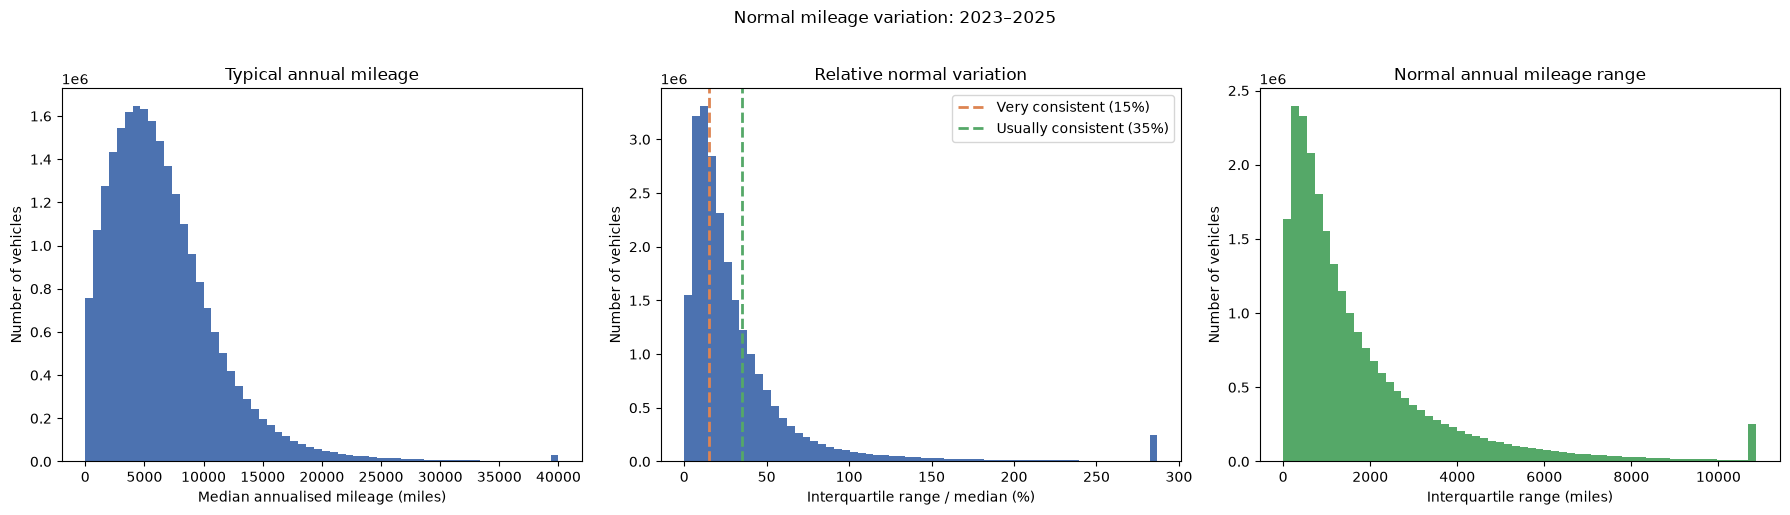

Summary values for the vehicles shown in the charts:
Vehicles with a full profile: 24,004,382
Typical annual mileage (miles):


,miles
p10,1644.128099
p25,3298.431122
median,5760.514286
p75,8832.777008
p90,12382.276860


Relative normal variation categories:


,vehicle_count,percentage
consistency_category,,
Very consistent,8496343,35.4%
Usually consistent,8519175,35.5%
Variable,6988864,29.1%


Relative normal variation (percent):


,percent
p10,6.169544
p25,11.294698
median,21.239089
p75,39.039948
p90,67.613732


Normal annual mileage range (interquartile range, miles):


,miles
p10,240.298522
p25,514.456664
median,1113.090271
p75,2294.946876
p90,4135.101485


In [11]:
typical_mileage = profiled_vehicles['typical_annual_mileage'].replace([np.inf, -np.inf], np.nan).dropna()
typical_mileage_upper_limit = max(40_000, typical_mileage.quantile(0.99))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(typical_mileage.clip(upper=typical_mileage_upper_limit), bins=60, color='#4C72B0')
axes[0].set_title('Typical annual mileage')
axes[0].set_xlabel('Median annualised mileage (miles)')
axes[0].set_ylabel('Number of vehicles')

relative_variation_percent = profiled_vehicles['relative_variation'].mul(100)
finite_relative_variation = relative_variation_percent[np.isfinite(relative_variation_percent)]
plot_upper_limit = max(50, finite_relative_variation.quantile(0.99))
axes[1].hist(finite_relative_variation.clip(upper=plot_upper_limit), bins=60, color='#4C72B0')
axes[1].axvline(15, color='#DD8452', linestyle='--', linewidth=2, label='Very consistent (15%)')
axes[1].axvline(35, color='#55A868', linestyle='--', linewidth=2, label='Usually consistent (35%)')
axes[1].set_title('Relative normal variation')
axes[1].set_xlabel('Interquartile range / median (%)')
axes[1].set_ylabel('Number of vehicles')
axes[1].legend()

plot_iqr_miles = profiled_vehicles['interquartile_range'].replace([np.inf, -np.inf], np.nan).dropna()
plot_iqr_upper_limit = max(2_000, plot_iqr_miles.quantile(0.99))
axes[2].hist(plot_iqr_miles.clip(upper=plot_iqr_upper_limit), bins=60, color='#55A868')
axes[2].set_title('Normal annual mileage range')
axes[2].set_xlabel('Interquartile range (miles)')
axes[2].set_ylabel('Number of vehicles')

plt.suptitle('Normal mileage variation: 2023–2025', y=1.02)
plt.tight_layout()
plt.show()

print('Summary values for the vehicles shown in the charts:')
print(f'Vehicles with a full profile: {len(profiled_vehicles):,}')

print('Typical annual mileage (miles):')
display(typical_mileage.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).rename({'10%': 'p10', '25%': 'p25', '50%': 'median', '75%': 'p75', '90%': 'p90'}).to_frame('miles').loc[['p10', 'p25', 'median', 'p75', 'p90']])

category_order = ['Very consistent', 'Usually consistent', 'Variable']
category_summary = profiled_vehicles['consistency_category'].value_counts().reindex(category_order, fill_value=0).to_frame('vehicle_count')
category_summary['percentage'] = category_summary['vehicle_count'].div(len(profiled_vehicles)).mul(100)
print('Relative normal variation categories:')
display(category_summary.assign(percentage=category_summary['percentage'].map(lambda value: f'{value:.1f}%')))

print('Relative normal variation (percent):')
display(finite_relative_variation.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).rename({'10%': 'p10', '25%': 'p25', '50%': 'median', '75%': 'p75', '90%': 'p90'}).to_frame('percent').loc[['p10', 'p25', 'median', 'p75', 'p90']])

print('Normal annual mileage range (interquartile range, miles):')
display(plot_iqr_miles.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).rename({'10%': 'p10', '25%': 'p25', '50%': 'median', '75%': 'p75', '90%': 'p90'}).to_frame('miles').loc[['p10', 'p25', 'median', 'p75', 'p90']])

## Estimated mileage by fuel type and postcode area

Each vehicle contributes its `typical_annual_mileage` once. For each fuel type and postcode area, the table reports the median estimated annual mileage, the 25th–75th percentile range, the mean, and the number of profiled vehicles. Only groups with at least `MIN_PEER_OBSERVATIONS` vehicles are included.

In [ ]:
def summarise_estimated_mileage_by_group(dataframe, group_column):
    clean_data = dataframe.dropna(subset=[group_column, 'typical_annual_mileage']).copy()
    clean_data = clean_data[np.isfinite(clean_data['typical_annual_mileage'])]
    grouped = clean_data.groupby(group_column, observed=True)
    summary = grouped.agg(
        vehicle_count=('vehicle_id', 'count'),
        estimated_annual_mileage=('typical_annual_mileage', 'median'),
        p25_annual_mileage=('typical_annual_mileage', lambda values: values.quantile(0.25)),
        p75_annual_mileage=('typical_annual_mileage', lambda values: values.quantile(0.75)),
        mean_annual_mileage=('typical_annual_mileage', 'mean'),
    )
    return summary.loc[summary['vehicle_count'] >= config.MIN_PEER_OBSERVATIONS].sort_values(
        'estimated_annual_mileage'
    )


def plot_estimated_mileage_by_group(summary, group_label, colour):
    if summary.empty:
        print(f'No {group_label.lower()} groups meet the minimum vehicle count.')
        return

    y_positions = np.arange(len(summary))
    median_values = summary['estimated_annual_mileage'].to_numpy()
    lower_errors = median_values - summary['p25_annual_mileage'].to_numpy()
    upper_errors = summary['p75_annual_mileage'].to_numpy() - median_values
    figure_height = max(4.5, min(30, 1.5 + len(summary) * 0.28))

    fig, axis = plt.subplots(figsize=(11, figure_height))
    axis.barh(y_positions, median_values, color=colour, alpha=0.85)
    axis.errorbar(
        median_values,
        y_positions,
        xerr=[lower_errors, upper_errors],
        fmt='none',
        ecolor='#333333',
        elinewidth=1.5,
        capsize=3,
    )
    axis.set_yticks(y_positions)
    axis.set_yticklabels(summary.index.astype(str))
    axis.set_xlabel('Estimated annual mileage: median typical mileage (miles)')
    axis.set_ylabel(group_label)
    axis.set_title(f'Estimated annual mileage by {group_label.lower()} (2023–2025)')
    axis.grid(axis='x', alpha=0.25)
    axis.set_axisbelow(True)
    plt.tight_layout()
    plt.show()


estimated_mileage_by_fuel_type = summarise_estimated_mileage_by_group(profiled_vehicles, 'fuel_type')
estimated_mileage_by_postcode_area = summarise_estimated_mileage_by_group(profiled_vehicles, 'postcode_area')

fuel_output_path = config.PROCESSED_DATA_DIR / 'estimated_mileage_by_fuel_type_2023_2025.parquet'
postcode_output_path = config.PROCESSED_DATA_DIR / 'estimated_mileage_by_postcode_area_2023_2025.parquet'
estimated_mileage_by_fuel_type.to_parquet(fuel_output_path)
estimated_mileage_by_postcode_area.to_parquet(postcode_output_path)

print('Estimated mileage by fuel type:')
display(estimated_mileage_by_fuel_type)
print('Estimated mileage by postcode area:')
display(estimated_mileage_by_postcode_area)

plot_estimated_mileage_by_group(estimated_mileage_by_fuel_type, 'Fuel type', '#4C72B0')
plot_estimated_mileage_by_group(estimated_mileage_by_postcode_area, 'Postcode area', '#55A868')

print(f'Saved fuel-type estimates to {fuel_output_path}')
print(f'Saved postcode-area estimates to {postcode_output_path}')